## 1. Muat Data

Pertama, kita akan memuat data gunung berapi dari URL yang diberikan ke dalam DataFrame pandas.

In [6]:
import pandas as pd

# URL dari dataset
url = 'https://raw.githubusercontent.com/yogski/indonesian_public_data/master/csv/indonesia_volcanoes.csv'

# Muat dataset ke dalam pandas DataFrame
df = pd.read_csv(url)

# Tampilkan beberapa baris pertama dan informasi tentang dataframe
print("Kepala DataFrame:")
display(df.head())

print("\nInfo DataFrame:")
df.info()

Kepala DataFrame:


,nama,bentuk,tinggi_meter,estimasi_letusan_terakhir,geolokasi
0,Weh,stratovulkan,617 meter,Pleistosen,5.82°N 95.28°E
1,Seulawah Agam,stratovulkan,1810 meter,1839,5.448°N 95.658°E
2,Peuet Sagoe,kompleks,2801 meter,25 Desember 2000,4.914°N 96.329°E
3,Geureudong,stratovulkan,2885 meter,1937,4.813°N 96.82°E
4,Kembar,perisai,2245 meter,Pleistosen,3.850°N 97.664°E



Info DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   nama                       150 non-null    object
 1   bentuk                     144 non-null    object
 2   tinggi_meter               148 non-null    object
 3   estimasi_letusan_terakhir  87 non-null     object
 4   geolokasi                  150 non-null    object
dtypes: object(5)
memory usage: 6.0+ KB


## 2. Persiapan Data (Langkah 1: Bersihkan `tinggi_meter`)

Kita akan membersihkan kolom `tinggi_meter` dengan mengekstrak hanya bagian numerik dan mengubahnya menjadi float. Kita juga akan memeriksa nilai yang hilang.

In [7]:
import numpy as np

# Bersihkan 'tinggi_meter' dengan mengekstrak angka dan mengubahnya menjadi float
df['tinggi_meter'] = df['tinggi_meter'].str.extract('(\d+)').astype(float)

# Periksa nilai yang hilang setelah membersihkan
print("Nilai yang hilang setelah membersihkan 'tinggi_meter':")
print(df.isnull().sum())

# Tampilkan kepala DataFrame yang diperbarui
print("\nKepala DataFrame setelah membersihkan 'tinggi_meter':")
display(df.head())

Nilai yang hilang setelah membersihkan 'tinggi_meter':
nama                          0
bentuk                        6
tinggi_meter                  2
estimasi_letusan_terakhir    63
geolokasi                     0
dtype: int64

Kepala DataFrame setelah membersihkan 'tinggi_meter':


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_10815/971198202.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['tinggi_meter'] = df['tinggi_meter'].str.extract('(\d+)').astype(float)


,nama,bentuk,tinggi_meter,estimasi_letusan_terakhir,geolokasi
0,Weh,stratovulkan,617.0,Pleistosen,5.82°N 95.28°E
1,Seulawah Agam,stratovulkan,1810.0,1839,5.448°N 95.658°E
2,Peuet Sagoe,kompleks,2801.0,25 Desember 2000,4.914°N 96.329°E
3,Geureudong,stratovulkan,2885.0,1937,4.813°N 96.82°E
4,Kembar,perisai,2245.0,Pleistosen,3.850°N 97.664°E


## 3. Analisis Data Eksplorasi (EDA) (Langkah 2: Visualisasikan kategori `bentuk`)

Sekarang, mari kita visualisasikan distribusi berbagai bentuk gunung berapi (`bentuk`) menggunakan countplot untuk memahami variabel target kita.

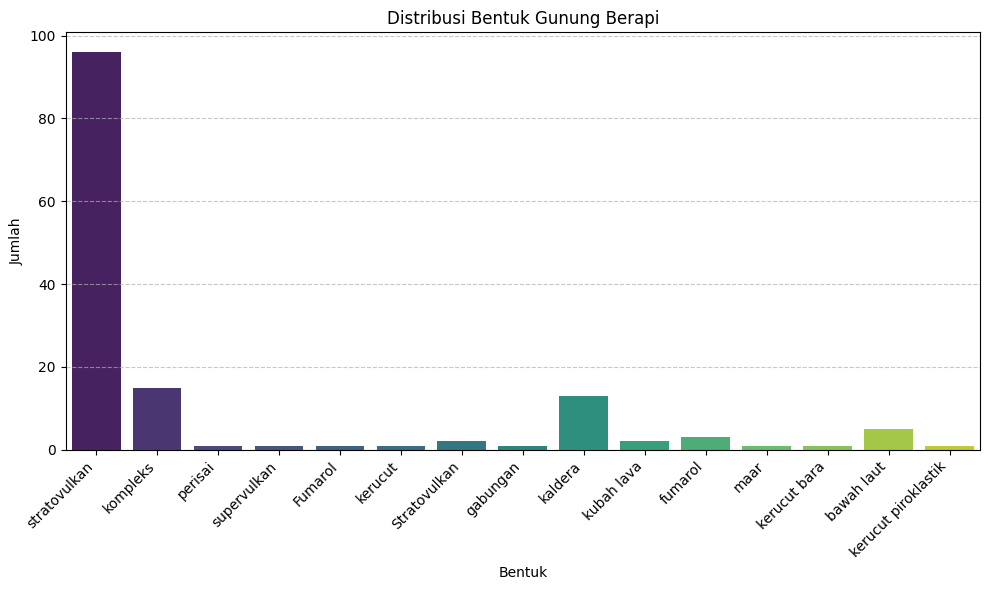

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='bentuk', palette='viridis', hue='bentuk', legend=False)
plt.title('Distribusi Bentuk Gunung Berapi')
plt.xlabel('Bentuk')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Rekayasa Fitur (Langkah 3: Ekstrak Koordinat)

Kami akan mengekstrak lintang dan bujur dari kolom `geolokasi` menggunakan ekspresi reguler dan mengubahnya menjadi fitur numerik. Kami akan menangani arah 'N'/'S' dan 'E'/'W' untuk mendapatkan koordinat bertanda yang benar.

### Referensi Pola Regex:
- Regex101: `[-+]?\d*\.\d+|\d+` untuk angka.
- Kami akan menggunakan pola yang lebih komprehensif untuk mengekstrak nilai dan arah.

In [9]:
import re

def extract_coordinates(geolokasi_str):
    if pd.isna(geolokasi_str):
        return np.nan, np.nan

    # Pola untuk mencocokkan lintang dan bujur dengan arahnya
    # Contoh: 5.82°N 95.28°E
    match = re.search(r'([-+]?\d+\.?\d*)°([NS])\s+([-+]?\d+\.?\d*)°([EW])',
                      geolokasi_str, re.IGNORECASE)
    if match:
        lat_val = float(match.group(1))
        lat_dir = match.group(2).upper()
        lon_val = float(match.group(3))
        lon_dir = match.group(4).upper()

        # Terapkan tanda berdasarkan arah
        latitude = lat_val if lat_dir == 'N' else -lat_val
        longitude = lon_val if lon_dir == 'E' else -lon_val

        return latitude, longitude
    return np.nan, np.nan # Kembalikan NaN jika tidak ada kecocokan

# Terapkan fungsi untuk membuat kolom 'lat' dan 'lon'
df[['lat', 'lon']] = df['geolokasi'].apply(lambda x: pd.Series(extract_coordinates(x)))

# Hapus kolom 'geolokasi' asli
df = df.drop(columns=['geolokasi'])

# Tampilkan DataFrame dengan kolom 'lat' dan 'lon' baru
print("Kepala DataFrame setelah rekayasa fitur:")
display(df.head())

print("\nNilai yang hilang setelah rekayasa fitur:")
print(df.isnull().sum())

Kepala DataFrame setelah rekayasa fitur:


,nama,bentuk,tinggi_meter,estimasi_letusan_terakhir,lat,lon
0,Weh,stratovulkan,617.0,Pleistosen,5.820,95.280
1,Seulawah Agam,stratovulkan,1810.0,1839,5.448,95.658
2,Peuet Sagoe,kompleks,2801.0,25 Desember 2000,4.914,96.329
3,Geureudong,stratovulkan,2885.0,1937,4.813,96.820
4,Kembar,perisai,2245.0,Pleistosen,3.850,97.664



Nilai yang hilang setelah rekayasa fitur:
nama                          0
bentuk                        6
tinggi_meter                  2
estimasi_letusan_terakhir    63
lat                           1
lon                           1
dtype: int64


## 5. Siapkan Data untuk Pelatihan Model

Kita perlu mendefinisikan fitur (X) dan target (y) kita. Untuk tugas klasifikasi ini, kita akan memprediksi `bentuk` (shape) gunung berapi menggunakan `tinggi_meter`, `lat`, dan `lon` sebagai fitur. Kita juga akan mengkodekan variabel target dan membagi data menjadi set pelatihan dan pengujian.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Hapus baris dengan nilai NaN yang tersisa (misalnya, dari masalah penguraian geolokasi)
df_cleaned = df.dropna().copy()

# Definisikan fitur (X) dan target (y)
X = df_cleaned[['tinggi_meter', 'lat', 'lon']]
y = df_cleaned['bentuk']

# Encode variabel target 'bentuk' menjadi label numerik
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Bagi data menjadi set pelatihan dan pengujian
# Menghapus 'stratify=y_encoded' karena ada kelas dengan hanya satu anggota.
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Kelas target asli: {label_encoder.classes_}")
print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"Bentuk y_test: {y_test.shape}")

Kelas target asli: ['Fumarol' 'bawah laut' 'kaldera' 'kerucut bara' 'kompleks' 'kubah lava'
 'perisai' 'stratovulkan' 'supervulkan']
Bentuk X_train: (69, 3)
Bentuk y_train: (69,)
Bentuk X_test: (18, 3)
Bentuk y_test: (18,)


## 6. Pelatihan Model (Langkah 4: Latih Random Forest Classifier)

Sekarang, kita akan melatih model `RandomForestClassifier` menggunakan data pelatihan yang telah kita siapkan.

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi model Random Forest Classifier
model = RandomForestClassifier(random_state=42)

# Latih model
model.fit(X_train, y_train)

print("Pelatihan model selesai.")

Pelatihan model selesai.


## 7. Validasi Model (Langkah 5: Periksa Akurasi)

Kita akan mengevaluasi kinerja model yang telah kita latih pada set pengujian menggunakan laporan klasifikasi, yang mencakup presisi, recall, f1-score, dan dukungan.

In [15]:
from sklearn.metrics import classification_report
import numpy as np

# Lakukan prediksi pada set pengujian
y_pred = model.predict(X_test)

# Dapatkan label unik yang ada di y_test dan y_pred
present_labels = np.unique(np.concatenate((y_test, y_pred)))

# Dapatkan nama kelas yang sesuai untuk laporan berdasarkan label yang ada
filtered_class_names = [label_encoder.classes_[label] for label in present_labels]

# Cetak laporan klasifikasi, tentukan parameter 'labels', 'target_names', dan 'zero_division'
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred, labels=present_labels, target_names=filtered_class_names, zero_division=0))

Laporan Klasifikasi:
              precision    recall  f1-score   support

  bawah laut       0.00      0.00      0.00         1
     kaldera       1.00      1.00      1.00         1
    kompleks       1.00      0.33      0.50         3
     perisai       0.00      0.00      0.00         1
stratovulkan       0.75      1.00      0.86        12

    accuracy                           0.78        18
   macro avg       0.55      0.47      0.47        18
weighted avg       0.72      0.78      0.71        18



## 8. Penyetelan (Langkah 6: Eksperimen Parameter)

Berikut adalah contoh bagaimana Anda dapat menyetel `RandomForestClassifier` dengan menyesuaikan hyperparameter seperti `n_estimators` (jumlah pohon) dan `max_depth` (kedalaman maksimum setiap pohon). Untuk penyetelan yang lebih menyeluruh, teknik seperti Grid Search atau Random Search dapat digunakan.

*Catatan: Karena ukuran dataset yang kecil, dampak penyetelan mungkin terbatas, tetapi ini menunjukkan konsepnya.*

In [17]:
# Contoh penyetelan model dengan parameter yang berbeda
model_tuned = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Latih model yang disetel
model_tuned.fit(X_train, y_train)

# Lakukan prediksi dengan model yang disetel
y_pred_tuned = model_tuned.predict(X_test)

# Dapatkan label unik yang ada di y_test dan y_pred_tuned
present_labels_tuned = np.unique(np.concatenate((y_test, y_pred_tuned)))

# Dapatkan nama kelas yang sesuai untuk laporan berdasarkan label yang ada
filtered_class_names_tuned = [label_encoder.classes_[label] for label in present_labels_tuned]

# Cetak laporan klasifikasi untuk model yang disetel
print("Laporan Klasifikasi untuk Model yang Disetel (n_estimators=100, max_depth=5):")
print(classification_report(y_test, y_pred_tuned, labels=present_labels_tuned, target_names=filtered_class_names_tuned, zero_division=0))

Laporan Klasifikasi untuk Model yang Disetel (n_estimators=100, max_depth=5):
              precision    recall  f1-score   support

  bawah laut       0.00      0.00      0.00         1
     kaldera       1.00      1.00      1.00         1
    kompleks       1.00      0.33      0.50         3
     perisai       0.00      0.00      0.00         1
stratovulkan       0.75      1.00      0.86        12

    accuracy                           0.78        18
   macro avg       0.55      0.47      0.47        18
weighted avg       0.72      0.78      0.71        18



## 9. Simpan Model yang Telah Dilatih

Akhirnya, kita akan menyimpan model yang telah dilatih (yang berkinerja terbaik, atau yang disetel) ke file `.joblib` sehingga dapat dimuat ulang dan digunakan nanti tanpa pelatihan ulang.

In [18]:
import joblib

# Definisikan nama file untuk model yang disimpan
model_filename = 'volcano_classifier_model.joblib'

# Simpan model (menggunakan `model` asli atau `model_tuned` jika kinerjanya lebih baik)
joblib.dump(model, model_filename)

print(f"Model berhasil disimpan ke '{model_filename}'")

# Anda dapat memuat kembali model menggunakan:
# loaded_model = joblib.load(model_filename)
# print("Model berhasil dimuat!")

Model berhasil disimpan ke 'volcano_classifier_model.joblib'


## 10. Penggunaan Model Tersimpan

Setelah model disimpan, Anda dapat memuatnya kembali dan menggunakannya untuk membuat prediksi pada data baru. Kita akan mendemonstrasikan prediksi untuk satu titik data dan beberapa titik data.

In [19]:
import joblib
import pandas as pd
import numpy as np

# Muat kembali model yang telah disimpan
loaded_model = joblib.load('volcano_classifier_model.joblib')
print("Model berhasil dimuat kembali!")

# Misalkan kita ingin membuat prediksi untuk gunung berapi baru.
# Kita perlu menyediakan 'tinggi_meter', 'lat', dan 'lon'.
# Data contoh harus dalam format DataFrame yang sama seperti X_train.

# --- Prediksi untuk satu titik data baru ---
# Contoh: Gunung berapi baru dengan tinggi 1500m, lat -7.0, lon 110.0
single_new_data = pd.DataFrame([{'tinggi_meter': 1500.0, 'lat': -7.0, 'lon': 110.0}])

single_prediction_encoded = loaded_model.predict(single_new_data)
single_prediction_class = label_encoder.inverse_transform(single_prediction_encoded)

print(f"\nPrediksi untuk satu titik data baru: {single_new_data.iloc[0].to_dict()}")
print(f"Bentuk gunung berapi yang diprediksi: {single_prediction_class[0]}")

Model berhasil dimuat kembali!

Prediksi untuk satu titik data baru: {'tinggi_meter': 1500.0, 'lat': -7.0, 'lon': 110.0}
Bentuk gunung berapi yang diprediksi: stratovulkan


In [21]:
import joblib
import pandas as pd
import numpy as np

# Muat kembali model yang telah disimpan
loaded_model = joblib.load('volcano_classifier_model.joblib')
print("Model berhasil dimuat kembali!")

# Misalkan kita ingin membuat prediksi untuk gunung berapi baru.
# Kita perlu menyediakan 'tinggi_meter', 'lat', dan 'lon'.
# Data contoh harus dalam format DataFrame yang sama seperti X_train.

# --- Prediksi untuk satu titik data baru ---
# Contoh: Gunung berapi baru dengan tinggi 1500m, lat -7.0, lon 110.0
single_new_data = pd.DataFrame([{'tinggi_meter': 1500.0, 'lat': -7.0, 'lon': 110.0}])

single_prediction_encoded = loaded_model.predict(single_new_data)
single_prediction_class = label_encoder.inverse_transform(single_prediction_encoded)

print(f"\nPrediksi untuk satu titik data baru: {single_new_data.iloc[0].to_dict()}")
print(f"Bentuk gunung berapi yang diprediksi: {single_prediction_class[0]}")

# --- Prediksi untuk beberapa titik data baru ---
# Contoh: Beberapa gunung berapi baru dengan rentang fitur yang lebih bervariasi
multi_new_data = pd.DataFrame([
    {'tinggi_meter': 2801.0, 'lat': 4.914, 'lon': 96.329},   # Mirip dengan 'kompleks'
    {'tinggi_meter': 617.0, 'lat': 5.820, 'lon': 95.280},    # Mirip dengan 'stratovulkan'
    {'tinggi_meter': 2245.0, 'lat': 3.850, 'lon': 97.664}    # Mirip dengan 'perisai'
])

multi_predictions_encoded = loaded_model.predict(multi_new_data)
multi_predictions_classes = label_encoder.inverse_transform(multi_predictions_encoded)

print(f"\nPrediksi untuk beberapa titik data baru:")
for i, data_point in multi_new_data.iterrows():
    print(f"Data: {data_point.to_dict()} -> Bentuk yang diprediksi: {multi_predictions_classes[i]}")

Model berhasil dimuat kembali!

Prediksi untuk satu titik data baru: {'tinggi_meter': 1500.0, 'lat': -7.0, 'lon': 110.0}
Bentuk gunung berapi yang diprediksi: stratovulkan

Prediksi untuk beberapa titik data baru:
Data: {'tinggi_meter': 2801.0, 'lat': 4.914, 'lon': 96.329} -> Bentuk yang diprediksi: kompleks
Data: {'tinggi_meter': 617.0, 'lat': 5.82, 'lon': 95.28} -> Bentuk yang diprediksi: stratovulkan
Data: {'tinggi_meter': 2245.0, 'lat': 3.85, 'lon': 97.664} -> Bentuk yang diprediksi: stratovulkan
